In [36]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import r2_score



In [7]:
dataset = Path("datasets")

In [8]:
concrete_data = pd.read_csv(dataset / "concrete_data.csv")

In [9]:
concrete_data.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [10]:
concrete_data.shape

(1030, 9)

In [11]:
concrete_data.describe()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


ValueError: Could not interpret value `csMPA` for `y`. An entry with this name does not appear in `data`.

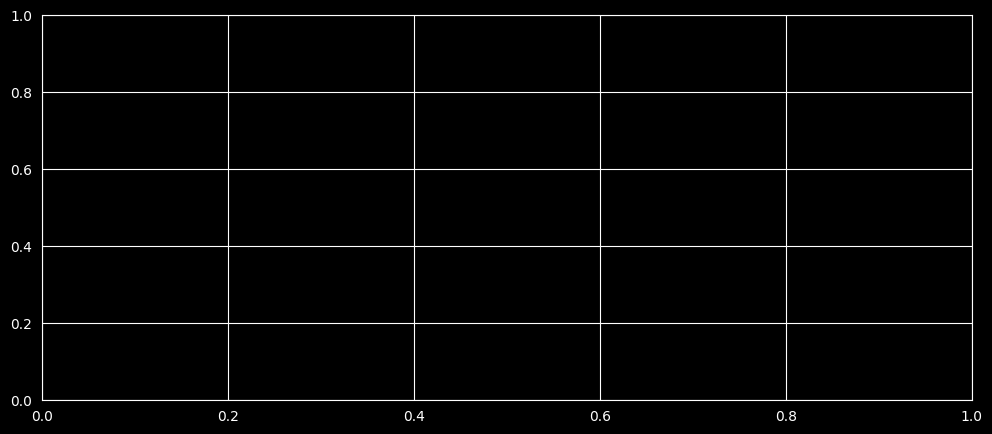

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.scatterplot(
    data=concrete_data,
    ax=ax,
    x="cement",
    y="csMPA",
    alpha=0.3
)

ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("")

ax.legend(title="", loc="top right", bbox_to_anchor=(1, 0.5))

fig.tight_layout()

# plt.savefig()
plt.show()

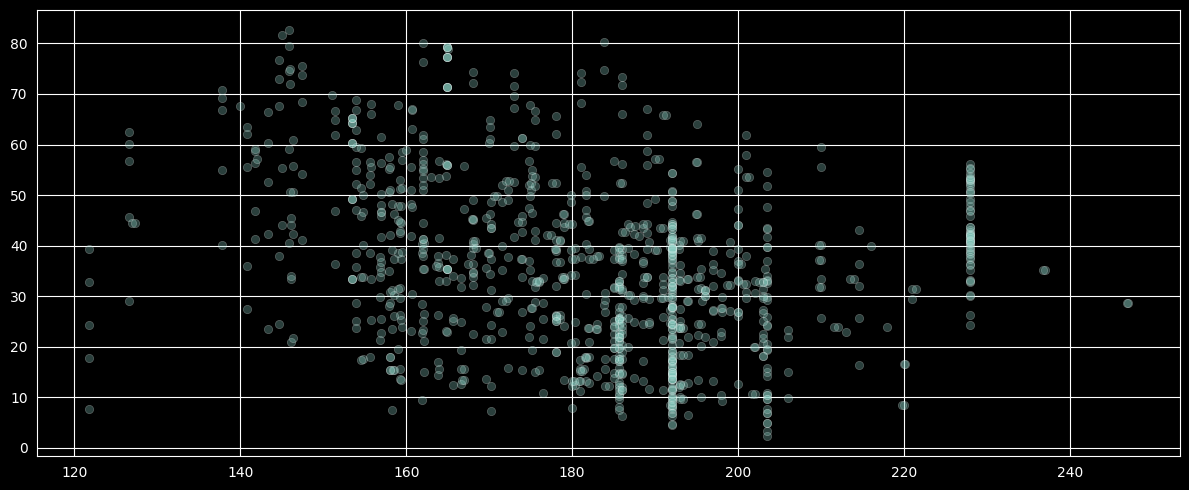

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.scatterplot(
    data=concrete_data,
    ax=ax,
    x="water",
    y="csMPa",
    alpha=0.3
)

ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("")

# ax.legend(title="", loc="top right", bbox_to_anchor=(1, 0.5))

fig.tight_layout()

# plt.savefig()
plt.show()

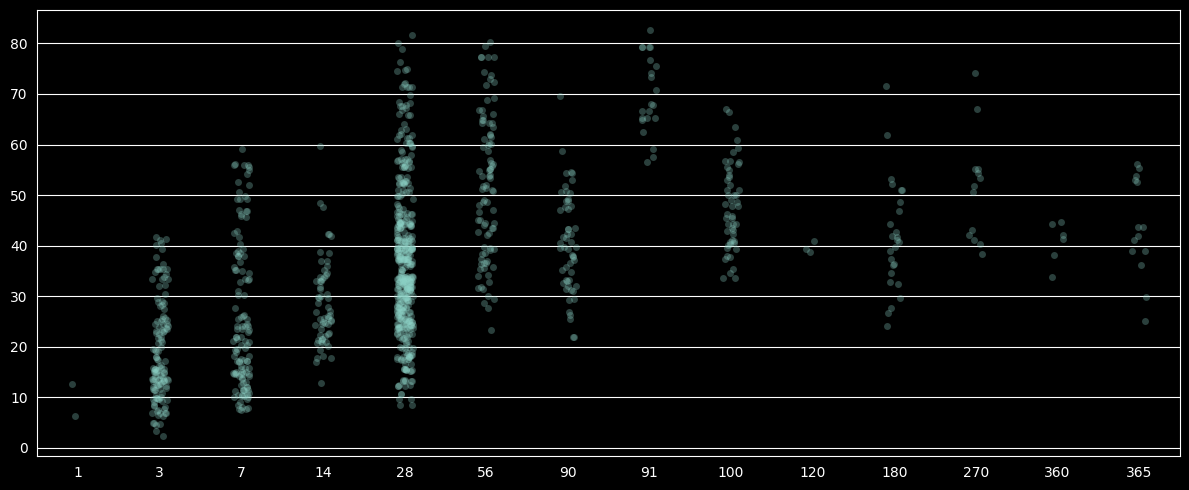

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.stripplot(
    data=concrete_data,
    ax=ax,
    x="age",
    y="csMPa",
    # hue="age",
    alpha=0.3
)

ax.set_title("Age vs csMPa")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# ax.legend(title="", loc="top right", bbox_to_anchor=(1, 0.5))

fig.tight_layout()

# plt.savefig()
plt.show()

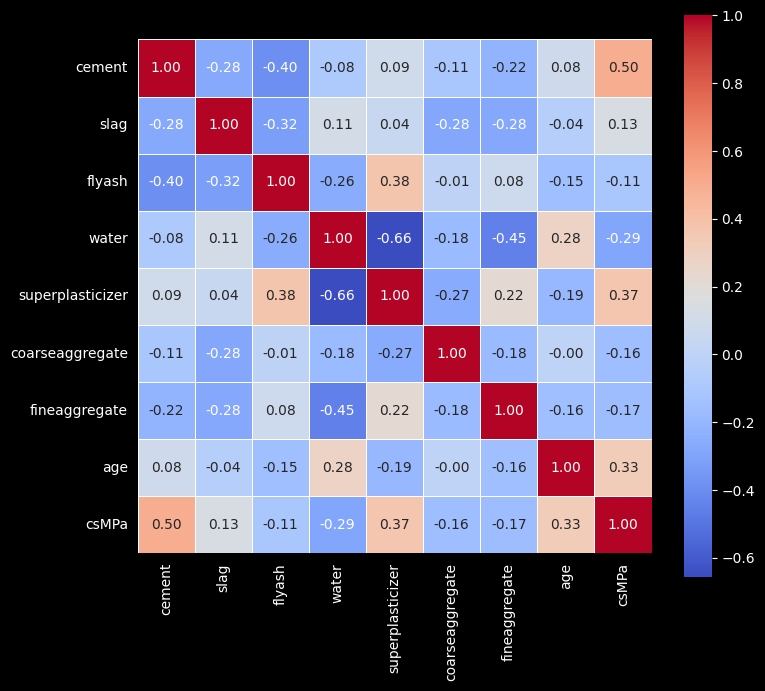

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    data=concrete_data.corr(),
    ax=ax,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": 0.8},
    cmap="coolwarm",
)

ax.set_title("", fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
X = concrete_data.drop(columns=["csMPa"])
y = concrete_data["csMPa"]

In [28]:
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.2)

In [30]:
bag_reg = BaggingRegressor(
    DecisionTreeRegressor(),
    n_estimators=500,
    bootstrap=False, # pasting (without replacments)
    max_samples=1.0,
    n_jobs=-1
)

In [31]:
bag_reg.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeRegressor()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",1.0
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",False
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [32]:
y_pred = bag_reg.predict(X_test)

In [33]:
df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

In [34]:
df.sample(10)

,Actual,Predicted
219,10.76,22.02250
798,55.16,47.22000
981,10.54,10.54000
163,66.60,64.90000
626,9.99,10.79550
724,35.76,34.68000
272,42.70,33.13662
784,13.52,13.50272
340,36.99,34.86232
47,40.76,40.56000


In [37]:
r2_score(y_test, y_pred)

# Model wyjaśnia 85% zmieności zmiennej docelowej (y).
# 85% wariancji wytrzymałości betonu (MPa) jest wyjaśnione przez cechy wejściowe
# 15% pozostaje nie wyjaśnione (szum, brakujące zmienne)

0.8573853580685478

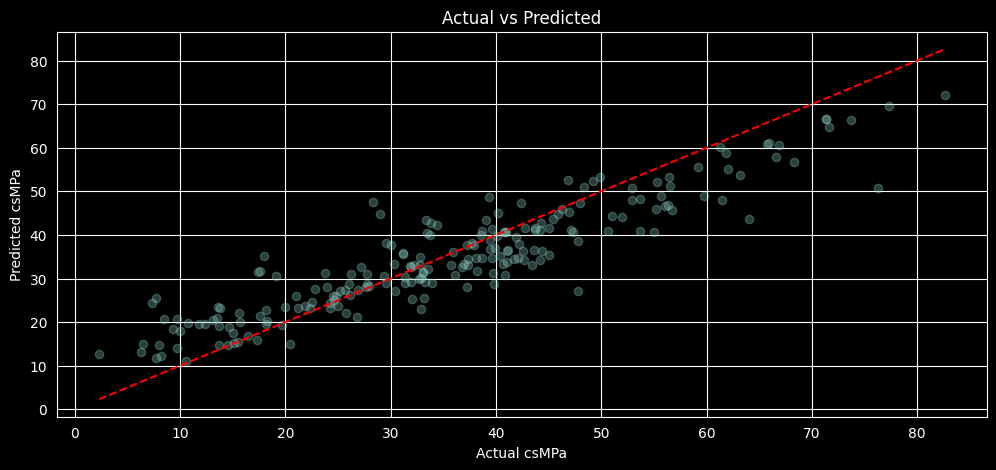

In [65]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.scatter(y_test, y_pred, alpha=0.3)
ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax.set_title("Actual vs Predicted")
ax.set_xlabel("Actual csMPa")
ax.set_ylabel("Predicted csMPa")
plt.show()

In [53]:
bag_reg = BaggingRegressor(
    DecisionTreeRegressor(),
    n_estimators=500,
    bootstrap=True, # bagging (with replacements)
    max_samples=0.8,
    n_jobs=-1,
    oob_score=True # out-of-bag
)

In [54]:
bag_reg.oob_score

True

In [55]:
bag_reg.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeRegressor()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.8
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [59]:
y_pred = bag_reg.predict(X_test)
df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
df.sample(10)

,Actual,Predicted
370,26.05,28.759020
927,33.05,30.926920
504,29.55,28.062056
268,47.82,42.101640
318,45.37,57.542260
923,39.84,31.806440
517,15.07,13.142640
757,18.13,18.494820
48,26.26,20.306560
511,65.70,62.376367


In [60]:
r2_score(y_test, y_pred)

0.9228176739698671

In [62]:
bag_reg = BaggingRegressor(
    DecisionTreeRegressor(),
    n_estimators=500,
    bootstrap=False,
    max_samples=1.0,
    bootstrap_features=True,
    max_features=0.8,
    n_jobs=-1,
)

In [63]:
bag_reg.fit(X_train, y_train)
y_pred = bag_reg.predict(X_test)
df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
df.sample(10)

,Actual,Predicted
365,38.60,40.064633
376,31.97,32.703344
869,31.18,35.626743
572,13.09,20.588833
278,43.58,36.444719
47,40.76,40.681399
10,38.07,34.655662
360,35.96,36.013540
443,37.27,28.021802
181,82.60,72.044174


In [64]:
r2_score(y_test, y_pred)

0.8203526995706115

In [71]:
bag_reg = BaggingRegressor(
    DecisionTreeRegressor(max_depth=10,
                          min_samples_leaf=5,
                          min_samples_split=10,
                          random_state=42),
    n_estimators=300,
    bootstrap=True,
    max_samples=0.7,
    n_jobs=-1,
    oob_score=True,
    random_state=42,

)
bag_reg.fit(X_train, y_train)
y_pred = bag_reg.predict(X_test)
df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
df.sample(10)
r2_score(y_test, y_pred)

0.8932135204922884

In [75]:
from sklearn.model_selection import GridSearchCV, KFold

In [78]:
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_samples": [0.6, 0.7, 0.8],
    "estimator__max_depth": [6, 8, 12, None],
    "estimator__min_samples_leaf": [1, 3, 5, 10],
    "estimator__min_samples_split": [2, 5, 10, 20]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=bag_reg,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=2,
)
grid.fit(X_train, y_train)
print("Best CV R2: ", grid.best_score_)
print("Best params: ", grid.best_params_)

best_model = grid.best_score_

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
[CV] END estimator__max_depth=6, estimator__min_samples_leaf=1, estimator__min_samples_split=2, max_samples=0.6, n_estimators=200; total time=   1.4s
[CV] END estimator__max_depth=6, estimator__min_samples_leaf=1, estimator__min_samples_split=2, max_samples=0.6, n_estimators=200; total time=   1.4s
[CV] END estimator__max_depth=6, estimator__min_samples_leaf=1, estimator__min_samples_split=2, max_samples=0.6, n_estimators=200; total time=   1.8s
[CV] END estimator__max_depth=6, estimator__min_samples_leaf=1, estimator__min_samples_split=2, max_samples=0.6, n_estimators=200; total time=   1.7s
[CV] END estimator__max_depth=6, estimator__min_samples_leaf=1, estimator__min_samples_split=2, max_samples=0.6, n_estimators=200; total time=   1.6s
[CV] END estimator__max_depth=6, estimator__min_samples_leaf=1, estimator__min_samples_split=2, max_samples=0.6, n_estimators=300; total time=   2.4s
[CV] END estimator__max_depth=6, est

In [79]:
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(
        random_state=42,
        max_depth=12,
        min_samples_leaf=1,
        min_samples_split=2
        ),
    bootstrap=True,
    n_jobs=-1,
    max_samples=0.8,
    n_estimators=300,
    random_state=42
)

bag_reg.fit(X_train, y_train)
y_pred = bag_reg.predict(X_test)

r2_score(y_test, y_pred)

0.9211227055738768